# BCS Regression — ViT backbone gelé + tête régression

**Objectif** : prédire le score BCS (Body Condition Score, 1–9) à partir des images du dataset Cats OGR, en utilisant :
1. **SAM 3** (mode point central) pour segmenter l'animal et masquer le fond
2. Le **ViT pré-entraîné** (132 races) comme extracteur de features gelé (embedding CLS 768-dim)
3. Un **petit MLP** (768→128→1) entraîné en régression

**Évaluation** : Leave-One-Cat-Out cross-validation (11 folds, 2 images par fold en test).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

print(f"Repo root : {REPO_ROOT}")

Repo root : /home/SPeillet/bcs_determination


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from pillow_heif import register_heif_opener
import pytorch_lightning as pl

register_heif_opener()
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : cuda


---
## 1. Chargement des données et annotation BCS

In [3]:
DATA_DIR = REPO_ROOT / "data" / "Cats_OGR_dataset"
excel_path = DATA_DIR / "BCS Excel Pra Ana Eiras - Master Thesis LC 2.xlsx"

df_data = pd.read_excel(excel_path, sheet_name="Data", header=2)
df_data = df_data.loc[:, ~df_data.columns.astype(str).str.startswith("Unnamed")]
df_data = df_data.rename(columns={"BCS_Score_1_9_AE": "BCS"})

images_dir = DATA_DIR / "images"

def resolve_image_file(photo_id):
    if pd.isna(photo_id):
        return None
    candidates = list(images_dir.glob(f"{photo_id}.*"))
    return str(candidates[0]) if candidates else None

rows = []
for _, r in df_data.iterrows():
    for view, col in [("LV", "Photo_LV_ID"), ("DV", "Photo_DV_ID")]:
        photo_id = r.get(col)
        path = resolve_image_file(photo_id)
        if path is None:
            continue
        rows.append({
            "Animal_ID": r["Animal_ID"],
            "view": view,
            "path": path,
            "BCS": float(r["BCS"]),
        })

df_obs = pd.DataFrame(rows)
print(f"{len(df_obs)} images, {df_obs['Animal_ID'].nunique()} chats, BCS ∈ [{df_obs['BCS'].min()}, {df_obs['BCS'].max()}]")
display(df_obs)

22 images, 11 chats, BCS ∈ [4.0, 6.0]


,Animal_ID,view,path,BCS
0,OGR_1,LV,/home/SPeillet/bcs_determination/data/Cats_OGR...,4.0
1,OGR_1,DV,/home/SPeillet/bcs_determination/data/Cats_OGR...,4.0
2,OGR_2,LV,/home/SPeillet/bcs_determination/data/Cats_OGR...,4.0
3,OGR_2,DV,/home/SPeillet/bcs_determination/data/Cats_OGR...,4.0
4,OGR_3,LV,/home/SPeillet/bcs_determination/data/Cats_OGR...,5.0
5,OGR_3,DV,/home/SPeillet/bcs_determination/data/Cats_OGR...,5.0
6,OGR_4,LV,/home/SPeillet/bcs_determination/data/Cats_OGR...,6.0
7,OGR_4,DV,/home/SPeillet/bcs_determination/data/Cats_OGR...,6.0
8,OGR_5,LV,/home/SPeillet/bcs_determination/data/Cats_OGR...,5.0
9,OGR_5,DV,/home/SPeillet/bcs_determination/data/Cats_OGR...,5.0


---
## 2. Pré-calcul des masques SAM3 (mode point central)

In [4]:
from bcs_pipeline.inference import (
    load_segmentation_backend,
    predict_segmentation_with,
)
from bcs_pipeline.app_checkpoints import SAM3_CKPT, SAM3_BPE

sam3_handle = load_segmentation_backend(
    "sam3", str(SAM3_CKPT),
    sam3_bpe_path=str(SAM3_BPE) if SAM3_BPE.is_file() else None,
    device=device,
)
print("✓ SAM 3 chargé")

# Pré-calculer les masques pour toutes les images
masks = []
for _, row in df_obs.iterrows():
    img = Image.open(row["path"]).convert("RGB")
    seg = predict_segmentation_with(
        "sam3", sam3_handle, img,
        sam3_mode="prompted",
    )
    # binary_mask: True = animal foreground
    masks.append(seg["binary_mask"])
    print(f"  {row['Animal_ID']}-{row['view']}: animal {(seg['binary_mask']).sum() / seg['binary_mask'].size * 100:.1f}%")

df_obs["mask"] = masks
print(f"\n✓ {len(masks)} masques pré-calculés")

/home/SPeillet/miniforge3/envs/bcs_analysis/lib/python3.10/site-packages/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/SPeillet/miniforge3/envs/bcs_analysis/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


✓ SAM 3 chargé
  OGR_1-LV: animal 24.8%
  OGR_1-DV: animal 19.9%
  OGR_2-LV: animal 22.3%
  OGR_2-DV: animal 21.4%
  OGR_3-LV: animal 22.2%
  OGR_3-DV: animal 14.7%
  OGR_4-LV: animal 24.4%
  OGR_4-DV: animal 20.0%
  OGR_5-LV: animal 38.1%
  OGR_5-DV: animal 11.1%
  OGR_6-LV: animal 21.7%
  OGR_6-DV: animal 26.9%
  OGR_7-LV: animal 18.1%
  OGR_7-DV: animal 1.0%
  OGR_8-LV: animal 21.3%
  OGR_8-DV: animal 11.1%
  OGR_9-LV: animal 7.5%
  OGR_9-DV: animal 0.3%
  OGR_10-LV: animal 23.7%
  OGR_10-DV: animal 15.9%
  OGR_11-LV: animal 18.2%
  OGR_11-DV: animal 15.7%

✓ 22 masques pré-calculés


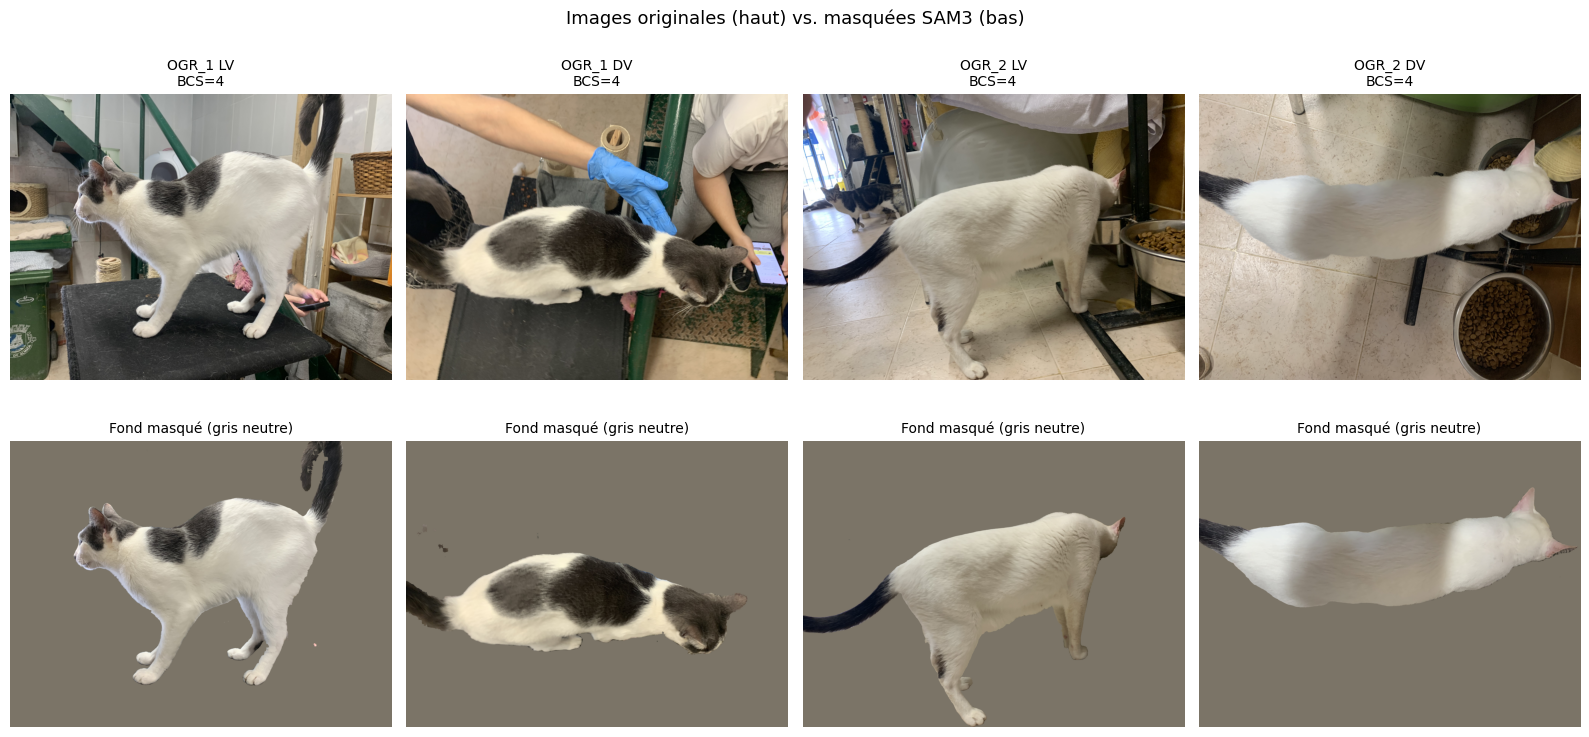

In [5]:
# Visualiser quelques exemples de masquage
from bcs_pipeline.data.bcs_datamodule import BCSDataset

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
sample_recs = df_obs.head(4).to_dict("records")
for i, rec in enumerate(sample_recs):
    # Original
    img = Image.open(rec["path"]).convert("RGB")
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"{rec['Animal_ID']} {rec['view']}\nBCS={rec['BCS']:.0f}", fontsize=10)
    axes[0, i].axis("off")
    # Masked
    masked = BCSDataset._apply_mask(img, rec["mask"])
    axes[1, i].imshow(masked)
    axes[1, i].set_title("Fond masqué (gris neutre)", fontsize=10)
    axes[1, i].axis("off")

plt.suptitle("Images originales (haut) vs. masquées SAM3 (bas)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Chargement des résultats (entraînement via script)

L'entraînement LOCO-CV est effectué via le script standalone :
```bash
python scripts/train_bcs_regression.py --max-epochs 80
```

Ce script sauvegarde :
- Un checkpoint par fold dans `checkpoints/bcs_regression/fold_<cat_id>/best.ckpt`
- Les prédictions globales dans `checkpoints/bcs_regression/predictions.json`

In [ ]:
import json
from bcs_pipeline.lightning_module.bcs_regression_module import LitBCSRegression
from bcs_pipeline.app_checkpoints import resolve_classifier_ckpt

# Chemin vers les résultats d'entraînement
BCS_CKPT_DIR = REPO_ROOT / "checkpoints" / "bcs_regression"
PREDICTIONS_PATH = BCS_CKPT_DIR / "predictions.json"
VIT_CKPT = str(resolve_classifier_ckpt())

print(f"Backbone ViT : {VIT_CKPT}")
print(f"Dossier checkpoints BCS : {BCS_CKPT_DIR}")
print(f"Fichier prédictions : {PREDICTIONS_PATH}")
assert PREDICTIONS_PATH.exists(), (
    f"Fichier non trouvé : {PREDICTIONS_PATH}\n"
    "→ Lancer d'abord : python scripts/train_bcs_regression.py"
)

Backbone ViT : /home/SPeillet/bcs_determination/checkpoints/classification/vit_dogs_cats/last.ckpt
Folds (Leave-One-Cat-Out) : 11 chats → 11 folds


In [ ]:
# Charger les prédictions depuis le fichier JSON produit par le script d'entraînement
with open(PREDICTIONS_PATH, "r") as f:
    results = json.load(f)

df_pred = pd.DataFrame(results["predictions"])

# Afficher la configuration d'entraînement
config = results["config"]
print(f"Configuration d'entraînement :")
print(f"  max_epochs = {config['max_epochs']}")
print(f"  batch_size = {config['batch_size']}")
print(f"  lr = {config['lr']}")
print(f"  hidden_dim = {config['hidden_dim']}")
print(f"  dropout = {config['dropout']}")
print(f"  sam3_mode = {config['sam3_mode']}")

print(f"\n{len(df_pred)} prédictions chargées ({df_pred['Animal_ID'].nunique()} chats)")
print(f"Temps d'entraînement total : {results['elapsed_seconds']:.1f}s")
display(df_pred)


Fold 1/11 — Test: OGR_1


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/SPeillet/miniforge3/envs/bcs_analysis/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/home/SPeillet/miniforge3/envs/bcs_analysis/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to i

RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu! (when checking argument for argument weight in method wrapper_CUDA__native_layer_norm)

In [ ]:
# (Optionnel) Charger un checkpoint pour inférence interactive
# Exemple : charger le modèle du premier fold
fold_info = results["folds"][0]
fold_ckpt = Path(fold_info["best_ckpt"])
print(f"Chargement checkpoint fold '{fold_info['fold_cat']}' : {fold_ckpt}")

if fold_ckpt.exists():
    model = LitBCSRegression.load_from_checkpoint(
        str(fold_ckpt),
        backbone_ckpt=VIT_CKPT,
        model_name="vit",
        num_classes=132,
    )
    model = model.float().to(device)
    model.eval()
    print(f"✓ Modèle chargé (fold {fold_info['fold_cat']}, {fold_info['epochs_trained']} epochs)")
else:
    print(f"⚠ Checkpoint non trouvé : {fold_ckpt}")

# Préparer les records pour les visualisations
records = df_obs.to_dict("records")
cat_ids = sorted(df_obs["Animal_ID"].unique())

---
## 4. Métriques globales

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(df_pred["BCS_actual"], df_pred["BCS_predicted"])
mse = mean_squared_error(df_pred["BCS_actual"], df_pred["BCS_predicted"])
rmse = np.sqrt(mse)
r2 = r2_score(df_pred["BCS_actual"], df_pred["BCS_predicted"])

print(f"{'Métrique':<15} {'Valeur':>8}")
print(f"{'-'*25}")
print(f"{'MAE':<15} {mae:>8.3f}")
print(f"{'RMSE':<15} {rmse:>8.3f}")
print(f"{'MSE':<15} {mse:>8.3f}")
print(f"{'R²':<15} {r2:>8.3f}")
print(f"\nPlage BCS dataset : [{df_pred['BCS_actual'].min():.0f}, {df_pred['BCS_actual'].max():.0f}]")
print(f"Plage prédictions  : [{df_pred['BCS_predicted'].min():.2f}, {df_pred['BCS_predicted'].max():.2f}]")

---
## 5. Visualisations

In [ ]:
# 5.1. Scatter plot : BCS prédit vs BCS réel
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df_pred["BCS_actual"], df_pred["BCS_predicted"],
           s=100, edgecolor="black", alpha=0.7, c="steelblue")

# Ligne parfaite
lims = [df_pred["BCS_actual"].min() - 0.5, df_pred["BCS_actual"].max() + 0.5]
ax.plot(lims, lims, "--", color="red", linewidth=2, label="Prédiction parfaite")

# Annoter chaque point
for _, r in df_pred.iterrows():
    ax.annotate(f"{r['Animal_ID'][-2:]}-{r['view']}",
                (r["BCS_actual"], r["BCS_predicted"]),
                fontsize=8, ha="left", va="bottom")

ax.set_xlabel("BCS réel (annotation expert)", fontsize=12)
ax.set_ylabel("BCS prédit (modèle)", fontsize=12)
ax.set_title(f"BCS prédit vs réel (Leave-One-Cat-Out)\nMAE={mae:.3f}, R²={r2:.3f}", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

In [ ]:
# 5.2. Bar chart par chat : BCS réel vs prédit
fig, ax = plt.subplots(figsize=(14, 5))

# Moyenner DV + LV par chat
df_cat = df_pred.groupby("Animal_ID").agg(
    BCS_actual=("BCS_actual", "first"),
    BCS_predicted=("BCS_predicted", "mean"),
).reset_index().sort_values("Animal_ID")

x_pos = np.arange(len(df_cat))
width = 0.35
bars1 = ax.bar(x_pos - width/2, df_cat["BCS_actual"], width,
               label="BCS réel", color="steelblue", edgecolor="black")
bars2 = ax.bar(x_pos + width/2, df_cat["BCS_predicted"], width,
               label="BCS prédit", color="coral", edgecolor="black")

ax.set_xticks(x_pos)
ax.set_xticklabels(df_cat["Animal_ID"], rotation=45)
ax.set_ylabel("Score BCS")
ax.set_title("BCS réel vs prédit par chat (moyenne DV+LV)")
ax.legend()
ax.set_ylim(0, 9)
ax.axhline(5, ls="--", color="green", alpha=0.5, label="BCS idéal")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# 5.3. Résidus (erreur par image)
df_pred["residual"] = df_pred["BCS_predicted"] - df_pred["BCS_actual"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme des résidus
axes[0].hist(df_pred["residual"], bins=10, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].axvline(0, color="red", linestyle="--", linewidth=2)
axes[0].set_xlabel("Résidu (prédit - réel)")
axes[0].set_ylabel("Nombre d'images")
axes[0].set_title("Distribution des résidus")

# Résidu par BCS réel
for view, marker in [("DV", "o"), ("LV", "s")]:
    sub = df_pred[df_pred["view"] == view]
    axes[1].scatter(sub["BCS_actual"], sub["residual"], marker=marker,
                    s=100, edgecolor="black", alpha=0.7, label=f"Vue {view}")
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("BCS réel")
axes[1].set_ylabel("Résidu (prédit - réel)")
axes[1].set_title("Résidus vs. BCS réel")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 5.4. Exemples d'images avec BCS prédit superposé
fig, axes = plt.subplots(3, 4, figsize=(18, 14))
axes = axes.flatten()

for i, (_, row) in enumerate(df_pred.head(12).iterrows()):
    ax = axes[i]
    img = Image.open(records[i]["path"]).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    error = row["BCS_predicted"] - row["BCS_actual"]
    color = "green" if abs(error) < 0.5 else "orange" if abs(error) < 1.0 else "red"
    ax.set_title(
        f"{row['Animal_ID']} {row['view']}\n"
        f"Réel: {row['BCS_actual']:.0f} | Prédit: {row['BCS_predicted']:.2f}",
        fontsize=10, color=color, fontweight="bold",
    )

plt.suptitle("Exemples : BCS réel vs prédit (vert=bon, orange=moyen, rouge=erreur)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Conclusions

| Aspect | Observation |
|--------|-------------|
| **Approche** | ViT gelé (132 races) + SAM3 masquage fond + MLP régression |
| **Évaluation** | Leave-One-Cat-Out (11 folds, 22 images) |
| **Métriques** | MAE, RMSE, R² |
| **Limites** | Très peu de données (11 chats), plage BCS étroite (4–6) |

### Pistes d'amélioration
- Augmenter le dataset (plus de chats, plus de variabilité BCS)
- Tester un backbone non gelé (fine-tune) si plus de données
- Ajouter des features morphologiques extraites du masque (aire, ratio, compacité)
- Multi-task : prédire BCS + catégorie (sous-poids / idéal / surpoids)